In [2]:
import yfinance as yf
import pandas as pd
import warnings
import mplfinance as mpf
from datetime import datetime, timedelta
warnings.simplefilter(action='ignore', category=FutureWarning)


In [ ]:
import yfinance as yf
import pandas as pd
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. 定義族群與對應的上市股票代號
stock_categories = {
    "半導體IC設計": ["2454.TW", "2379.TW", "3034.TW", "3443.TW", "4961.TW"],
    "晶圓代工與封測": ["2330.TW", "2303.TW", "3711.TW", "2449.TW", "6770.TW"],
    "半導體設備與材料": ["2404.TW", "6139.TW", "3413.TW", "3583.TW", "3532.TW"]
}

# 2. 映射字典
company_names = {
    "2454": "聯發科", "2379": "瑞昱", "3034": "聯詠", "3443": "創意", "4961": "天鈺",
    "2330": "台積電", "2303": "聯電", "3711": "日月光投控", "2449": "京元電子", "6770": "力積電",
    "2404": "漢唐", "6139": "亞翔", "3413": "京鼎", "3583": "辛耘", "3532": "台勝科"
}

def generate_daily_individual_report_with_date():
    print("啟動具備日期識別功能的個股盤後數據監控系統...\n")
    report_data = []

    for category, tickers in stock_categories.items():
        try:
            # 抓取近 5 天資料，確保覆蓋週末與休假日
            data = yf.download(tickers, period="5d", group_by='ticker')
        except Exception as e:
            print(f"數據下載衝突 {category}: {e}")
            continue

        for ticker in tickers:
            if ticker in data.columns.levels[0]:
                t_data = data[ticker][['Open', 'High', 'Low', 'Close']].dropna()
                
                if not t_data.empty:
                    # 3. 提取最新有效交易日的數據與日期
                    latest_entry = t_data.iloc[-1:]
                    # 取得索引日期並轉換為字串格式 (YYYY-MM-DD)
                    data_date = latest_entry.index[0].strftime('%Y-%m-%d')
                    
                    val = latest_entry.iloc[0]
                    open_p = round(val['Open'], 2)
                    close_p = round(val['Close'], 2)
                    
                    # 4. 盤中漲跌邏輯判定
                    if close_p > open_p:
                        trend = "漲"
                    elif close_p < open_p:
                        trend = "跌"
                    else:
                        trend = "平"

                    stock_id = ticker.replace(".TW", "")
                    
                    report_data.append({
                        "資料日期": data_date,
                        "所屬族群": category,
                        "股票代號": stock_id,
                        "公司名稱": company_names.get(stock_id, "未知"),
                        "開盤價": open_p,
                        "最高價": round(val['High'], 2),
                        "最低價": round(val['Low'], 2),
                        "收盤價": close_p,
                        "當日盤中漲跌": trend
                    })

    if report_data:
        df_report = pd.DataFrame(report_data)
        pd.set_option('display.unicode.east_asian_width', True) 
        # 依據日期與族群排序，提升報表專業度
        df_report = df_report.sort_values(by=["資料日期", "所屬族群"], ascending=[False, True])
        print(df_report.to_string(index=False))
    else:
        print("未偵測到有效交易日數據。")

if __name__ == "__main__":
    generate_daily_individual_report_with_date()

啟動具備日期識別功能的個股盤後數據監控系統...



[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed

  資料日期         所屬族群 股票代號   公司名稱  開盤價  最高價  最低價  收盤價 當日盤中漲跌
2026-04-10     半導體IC設計     2454     聯發科  1600.0  1605.0  1570.0  1575.0           跌
2026-04-10     半導體IC設計     2379       瑞昱   510.0   516.0   506.0   508.0           跌
2026-04-10     半導體IC設計     3034       聯詠   401.5   401.5   393.5   394.0           跌
2026-04-10     半導體IC設計     3443       創意  2695.0  2720.0  2645.0  2665.0           跌
2026-04-10     半導體IC設計     4961       天鈺   156.0   157.0   152.5   153.0           跌
2026-04-10 半導體設備與材料     2404       漢唐   924.0   950.0   917.0   926.0           漲
2026-04-10 半導體設備與材料     6139       亞翔   615.0   646.0   600.0   636.0           漲
2026-04-10 半導體設備與材料     3413       京鼎   313.0   322.5   313.0   315.0           漲
2026-04-10 半導體設備與材料     3583       辛耘   626.0   673.0   625.0   673.0           漲
2026-04-10 半導體設備與材料     3532     台勝科   153.0   165.5   152.0   165.5           漲
2026-04-10   晶圓代工與封測     2330     台積電  1975.0  2000.0  1970.0  2000.0           漲
2026-04-10   晶圓代工與封測     2

[*********************100%***********************]  5 of 5 completed

--- 正在計算等權重基準化：半導體IC設計 ---


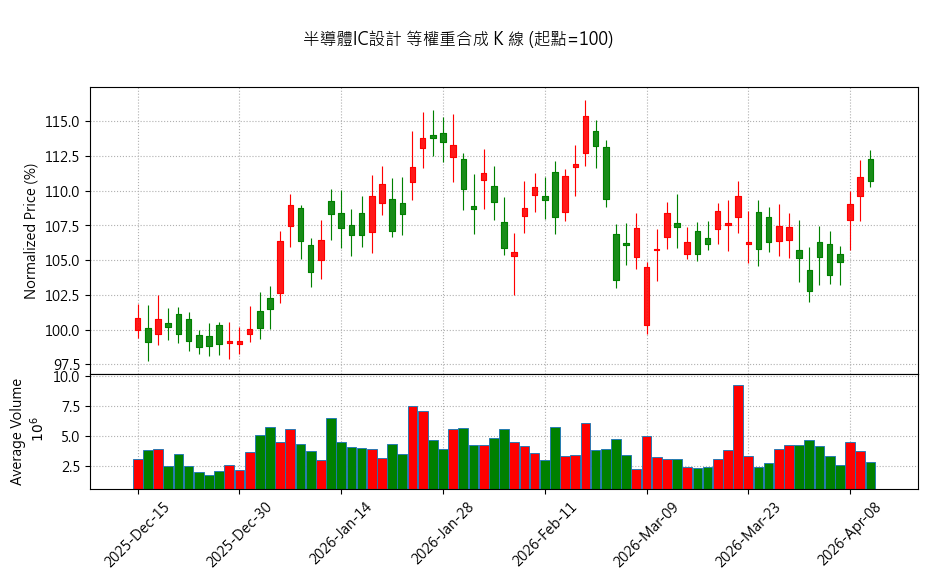

[*******************   40%                       ]  2 of 5 completed

--- 正在計算等權重基準化：晶圓代工與封測 ---


[*********************100%***********************]  5 of 5 completed


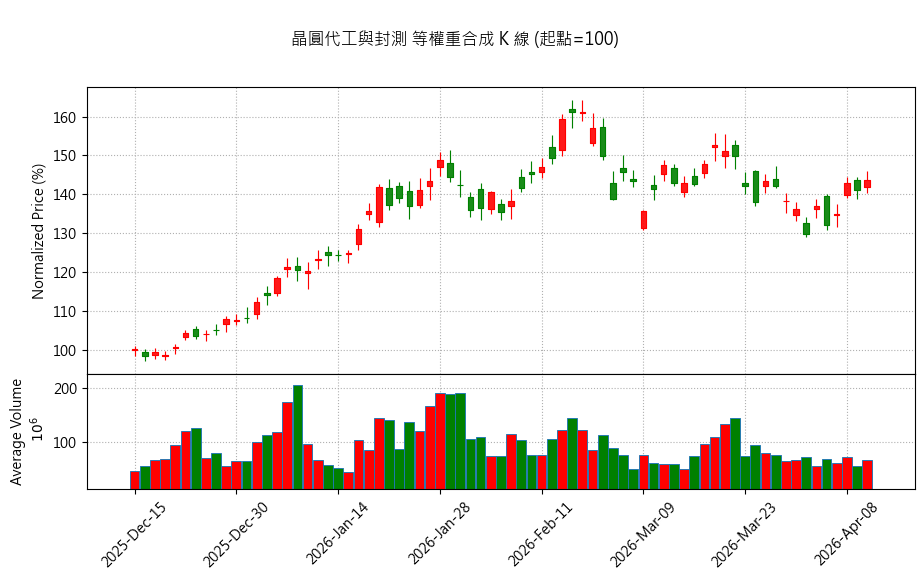

[*******************   40%                       ]  2 of 5 completed

--- 正在計算等權重基準化：半導體設備與材料 ---


[*********************100%***********************]  5 of 5 completed


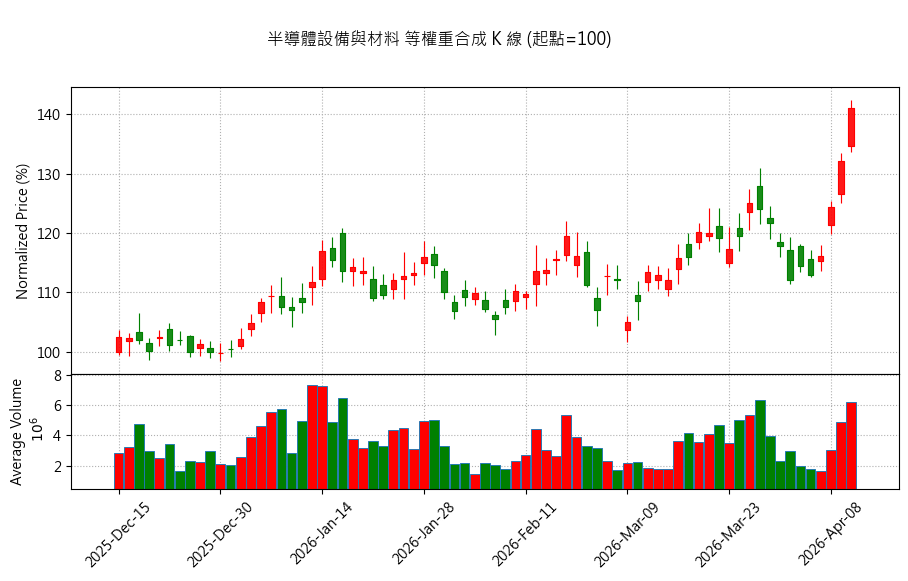

In [6]:
stock_categories = {
    "半導體IC設計": ["2454.TW", "2379.TW", "3034.TW", "3443.TW", "4961.TW"],
    "晶圓代工與封測": ["2330.TW", "2303.TW", "3711.TW", "2449.TW", "6770.TW"],
    "半導體設備與材料": ["2404.TW", "6139.TW", "3413.TW", "3583.TW", "3532.TW"]
}

def process_normalized_kline():
    end_date = datetime.now()
    start_date = end_date - timedelta(days=120)

    for category, tickers in stock_categories.items():
        print(f"--- 正在計算等權重基準化：{category} ---")
        
        data = yf.download(tickers, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), group_by='ticker')
        if data.empty: continue

        composite_df = pd.DataFrame()
        valid_count = 0

        for ticker in tickers:
            if ticker in data.columns.levels[0]:
                t_data = data[ticker][['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
                
                if not t_data.empty:
                    # 【核心修正】：基準化處理 (Normalization)
                    # 抓取該檔股票觀察期內的第一天開盤價作為基準 (Base = 100)
                    base_price = t_data['Open'].iloc[0]
                    
                    # 將 OHLC 數值全部轉換為相對百分比
                    normalized_data = t_data[['Open', 'High', 'Low', 'Close']] / base_price * 100
                    
                    # 成交量不適合基準化，維持原數值相加（稍後需留意量能解讀）
                    normalized_data['Volume'] = t_data['Volume']
                    
                    if composite_df.empty:
                        composite_df = normalized_data.copy()
                    else:
                        composite_df += normalized_data
                    valid_count += 1
        
        if valid_count > 0:
            # 數值相加後除以檔數，形成完全等權重的平均報酬 K 線
            composite_df = composite_df / valid_count
            
            my_rc = {'font.family': ['Microsoft JhengHei', 'sans-serif'], 'axes.unicode_minus': False}
            mc = mpf.make_marketcolors(up='r', down='g', edge='inherit', wick='inherit', volume='in')
            s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', rc=my_rc)
            
            mpf.plot(composite_df, 
                     type='candle', 
                     style=s, 
                     volume=True, 
                     # 標題加上 (Base=100) 以識別這是基準化數據
                     title=f"\n{category} 等權重合成 K 線 (起點=100)",
                     ylabel='Normalized Price (%)', 
                     ylabel_lower='Average Volume',
                     figratio=(12, 6))

if __name__ == "__main__":
    process_normalized_kline()